# Qualitative Analysis - Phase 6D

Looking at what the trained agent actually learned. Using the phase 5 CNN with reward shaping (soft path + block) on 7x7.

## 1. Setup

In [68]:
import os, sys, math, random
from copy import deepcopy
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from hex_engine import hexPosition, RED, BLUE, EMPTY
from models import ConvDQN, board_to_spatial_tensor

CKPT = os.path.join(PROJECT_ROOT, 'results', 'phase5_cnn_reward_shaping_soft_path_block_7x7_best.pt')

checkpoint = torch.load(CKPT, map_location='cpu', weights_only=False)
BOARD_SIZE = checkpoint.get('board_size', 7)

model = ConvDQN(board_size=BOARD_SIZE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('board size:', BOARD_SIZE)
print('episodes:  ', checkpoint.get('episodes'))
print('reward components:', checkpoint.get('reward_components'))

board size: 7
episodes:   1500
reward components: ['center_control', 'stone_progress', 'path_potential', 'blocking']


In [69]:
# The model was trained always as RED. When it's BLUE's turn we mirror
# the board and swap colors so the network sees a RED-to-play position.
# Same trick as in facade.py.

def transform_move_for_blue(move, n):
    r, c = move
    return n - 1 - c, n - 1 - r

def canonical_board(board, player):
    n = len(board)
    if player == RED:
        return board
    out = [[EMPTY]*n for _ in range(n)]
    for r in range(n):
        for c in range(n):
            v = board[n-1-c][n-1-r]
            out[r][c] = -v
    return out

def legal_moves(board):
    n = len(board)
    return [(r, c) for r in range(n) for c in range(n) if board[r][c] == EMPTY]

def q_values_for(board, player):
    # Returns Q grid in the canonical (RED) frame. Illegal cells = NaN.
    n = len(board)
    cb = canonical_board(board, player)
    with torch.no_grad():
        x = board_to_spatial_tensor(cb, device='cpu')
        q = model(x).squeeze(0).cpu().numpy().reshape(n, n).astype(np.float32)
    q[np.array(cb) != EMPTY] = np.nan
    return q, cb

def best_move(board, player):
    n = len(board)
    q, _ = q_values_for(board, player)
    idx = int(np.nanargmax(q.flatten()))
    mv = (idx // n, idx % n)
    return transform_move_for_blue(mv, n) if player == BLUE else mv

def softmax(x, tau=1.0):
    x = x - np.nanmax(x)
    e = np.exp(x / tau)
    e[np.isnan(e)] = 0
    return e / e.sum() if e.sum() > 0 else e

In [70]:
_SQRT3 = math.sqrt(3)

def _cell_xy(r, c):
    return c * _SQRT3 + r * (_SQRT3 / 2), -r * 1.5

def draw_board(board, q=None, title='', ax=None, highlight=None, show_values=True, cmap='viridis'):
    n = len(board)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)

    if q is not None:
        qfin = q[~np.isnan(q)]
        qmin = float(qfin.min()) if qfin.size else 0.0
        qmax = float(qfin.max()) if qfin.size else 1.0
        qrng = qmax - qmin if qmax > qmin else 1.0
    cm = plt.get_cmap(cmap)

    for r in range(n):
        for c in range(n):
            x, y = _cell_xy(r, c)
            v = board[r][c]
            if v == RED:
                face = '#d33'
            elif v == BLUE:
                face = '#36c'
            elif q is not None and not np.isnan(q[r, c]):
                face = cm((q[r, c] - qmin) / qrng)
            else:
                face = 'white'

            ax.add_patch(RegularPolygon((x, y), numVertices=6, radius=1.0,
                                        orientation=math.radians(30),
                                        facecolor=face, edgecolor='black', lw=1.2))

            if v == EMPTY and q is not None and show_values and not np.isnan(q[r, c]):
                ax.text(x, y, f'{q[r,c]:.2f}', ha='center', va='center', fontsize=7, color='white')
            elif v == RED:
                ax.text(x, y, 'R', ha='center', va='center', fontsize=10, color='white', weight='bold')
            elif v == BLUE:
                ax.text(x, y, 'B', ha='center', va='center', fontsize=10, color='white', weight='bold')

    if highlight is not None:
        for (hr, hc) in (highlight if isinstance(highlight, list) else [highlight]):
            x, y = _cell_xy(hr, hc)
            ax.add_patch(RegularPolygon((x, y), numVertices=6, radius=1.0,
                                        orientation=math.radians(30),
                                        facecolor='none', edgecolor='gold', lw=3))

    xs = [_cell_xy(r, c)[0] for r in range(n) for c in range(n)]
    ys = [_cell_xy(r, c)[1] for r in range(n) for c in range(n)]
    ax.set_xlim(min(xs)-1.2, max(xs)+1.2)
    ax.set_ylim(min(ys)-1.2, max(ys)+1.2)
    return ax

## 2. Opening (RED)

On an empty board, which cell does the agent want most?

best opening move (RED): (3, 6)


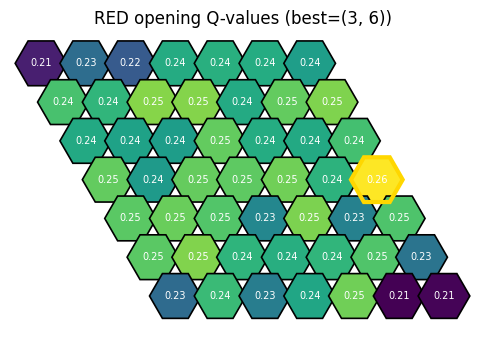

top 5:
  (3, 6)  Q=0.260
  (1, 2)  Q=0.250
  (1, 3)  Q=0.250
  (5, 1)  Q=0.250
  (1, 6)  Q=0.250


In [71]:
empty = [[EMPTY]*BOARD_SIZE for _ in range(BOARD_SIZE)]
q, _ = q_values_for(empty, RED)
bm = best_move(empty, RED)

print('best opening move (RED):', bm)
draw_board(empty, q, title=f'RED opening Q-values (best={bm})', highlight=bm)
plt.show()

ranked = sorted([(i, v) for i, v in enumerate(q.flatten()) if not np.isnan(v)],
                key=lambda t: -t[1])
print('top 5:')
for i, v in ranked[:5]:
    print(f'  {(i//BOARD_SIZE, i%BOARD_SIZE)}  Q={v:.3f}')

## 3. Strategic probes (RED)

Three hand-built positions to see if the agent picks the obvious move:
1. complete a 2-bridge
2. block the opponent who is one move from winning
3. finish a near-complete connection at the right edge

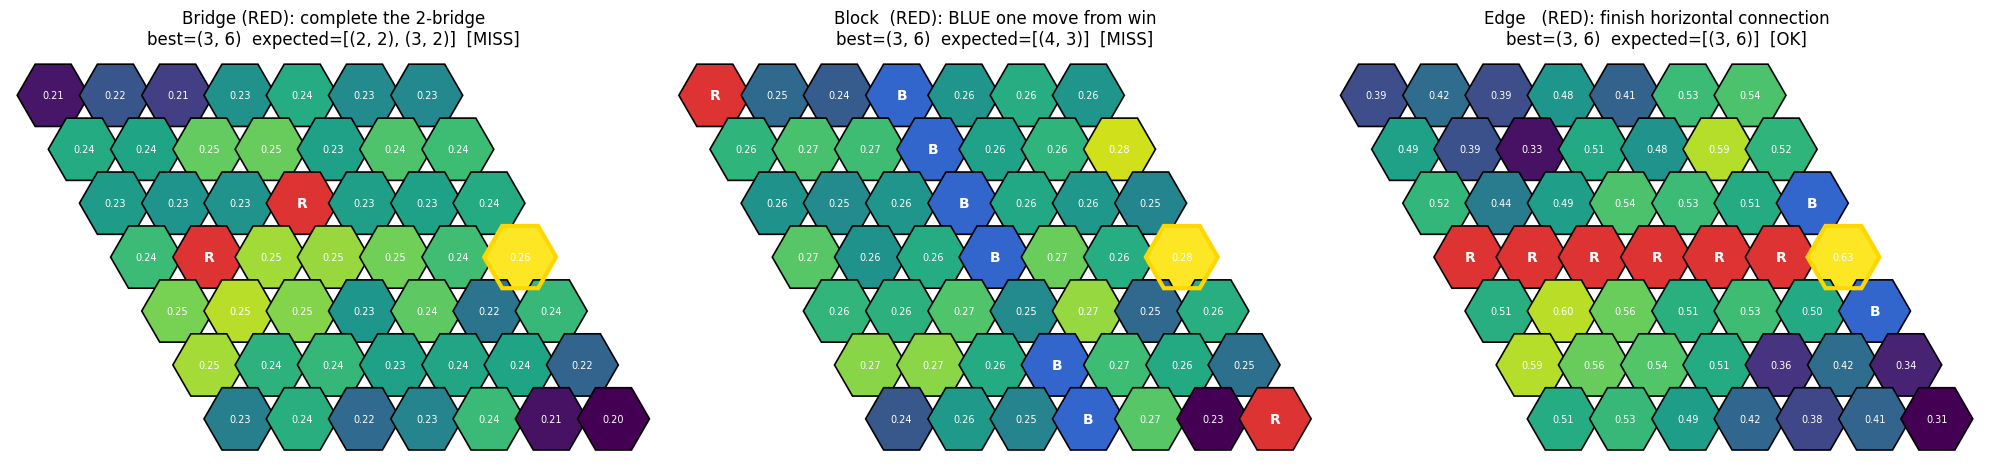

In [72]:
def make_board(stones):
    b = [[EMPTY]*BOARD_SIZE for _ in range(BOARD_SIZE)]
    for (r, c), v in stones.items():
        b[r][c] = v
    return b

# 2-bridge: RED stones at (3,1) and (2,3), bridge cells (2,2) and (3,2)
bridge_board = make_board({(3,1): RED, (2,3): RED})

# BLUE is one stone away from a vertical win in column 3, missing (4,3)
block_board = make_board({(0,3):BLUE,(1,3):BLUE,(2,3):BLUE,(3,3):BLUE,(5,3):BLUE,(6,3):BLUE,
                          (0,0):RED,(6,6):RED})

# RED almost connects left-to-right along row 3, only (3,6) missing
edge_board = make_board({(3,0):RED,(3,1):RED,(3,2):RED,(3,3):RED,(3,4):RED,(3,5):RED,
                         (2,6):BLUE,(4,6):BLUE})

probes = [
    ('Bridge (RED): complete the 2-bridge',          bridge_board, RED, [(2,2),(3,2)]),
    ('Block  (RED): BLUE one move from win',         block_board,  RED, [(4,3)]),
    ('Edge   (RED): finish horizontal connection',   edge_board,   RED, [(3,6)]),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, b, p, expected) in zip(axes, probes):
    q, _ = q_values_for(b, p)
    bm = best_move(b, p)
    ok = 'OK' if bm in expected else 'MISS'
    draw_board(b, q, title=f'{title}\nbest={bm}  expected={expected}  [{ok}]',
               highlight=bm, ax=ax)
plt.tight_layout(); plt.show()

## 4. Self-play stats vs baselines

Run the agent against random and a simple greedy-center baseline. Collect win rates,
average game length, first-move heatmap and full move-frequency heatmap.

In [73]:
def model_agent(board, action_set):
    red  = sum(v == RED  for row in board for v in row)
    blue = sum(v == BLUE for row in board for v in row)
    player = RED if red == blue else BLUE
    mv = best_move(board, player)
    return mv if mv in action_set else random.choice(action_set)

def random_agent(board, action_set):
    return random.choice(action_set)

def greedy_center_agent(board, action_set):
    center = (len(board)//2, len(board)//2)
    return min(action_set, key=lambda m: abs(m[0]-center[0]) + abs(m[1]-center[1]))

def play(agent_red, agent_blue, n_games=50, board_size=BOARD_SIZE):
    n = board_size
    first_move = np.zeros((n, n))
    all_moves  = np.zeros((n, n))
    wins = {RED: 0, BLUE: 0}
    lengths = []
    for _ in range(n_games):
        game = hexPosition(size=board_size)
        m = 0
        while game.winner == EMPTY:
            acts = legal_moves(game.board)
            mover = agent_red if game.player == RED else agent_blue
            mv = mover([row[:] for row in game.board], acts)
            if m == 0 and game.player == RED:
                first_move[mv] += 1
            all_moves[mv] += 1
            game.move(mv)
            m += 1
            if m > board_size*board_size:
                break
        wins[game.winner] = wins.get(game.winner, 0) + 1
        lengths.append(m)
    return first_move, all_moves, wins, lengths

random.seed(0); torch.manual_seed(0)
fm_r, am_r, wins_r, len_r = play(model_agent, random_agent,        n_games=50)
fm_g, am_g, wins_g, len_g = play(model_agent, greedy_center_agent, n_games=50)
print('vs random :', wins_r, 'avg len', np.mean(len_r))
print('vs greedy :', wins_g, 'avg len', np.mean(len_g))

vs random : {1: 49, -1: 1} avg len 16.02
vs greedy : {1: 0, -1: 50} avg len 36.0


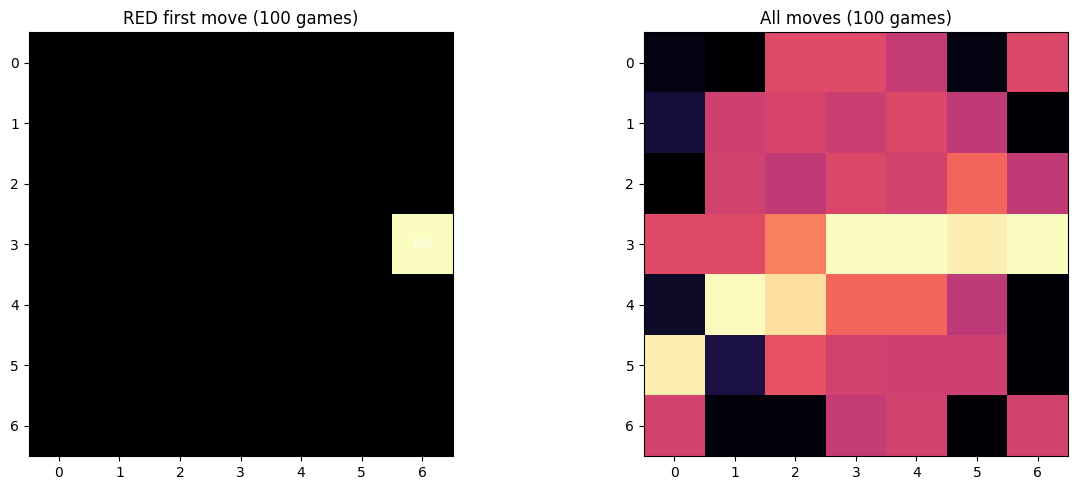

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fm = fm_r + fm_g
axes[0].imshow(fm, cmap='magma')
axes[0].set_title('RED first move (100 games)')
for r in range(BOARD_SIZE):
    for c in range(BOARD_SIZE):
        if fm[r, c] > 0:
            axes[0].text(c, r, int(fm[r, c]), ha='center', va='center', color='white', fontsize=8)

am = am_r + am_g
axes[1].imshow(am, cmap='magma')
axes[1].set_title('All moves (100 games)')

plt.tight_layout(); plt.show()

## 5. Decision confidence

Softmax-entropy of the Q distribution per move during one game vs random.
Low entropy = the agent strongly prefers one move (a "critical decision").
High entropy = it's basically indifferent.

winner: RED
entropies: [3.89, 3.85, 3.81, 3.76, 3.71, 3.66, 3.61, 3.54]


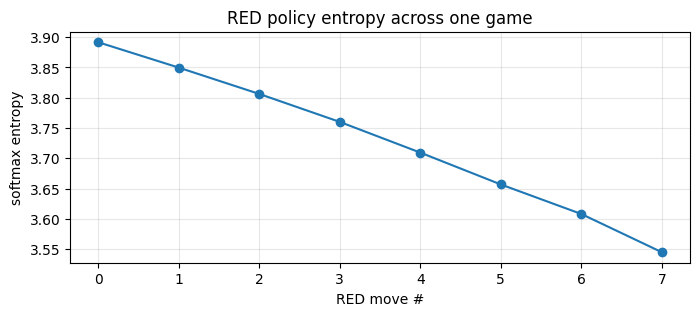

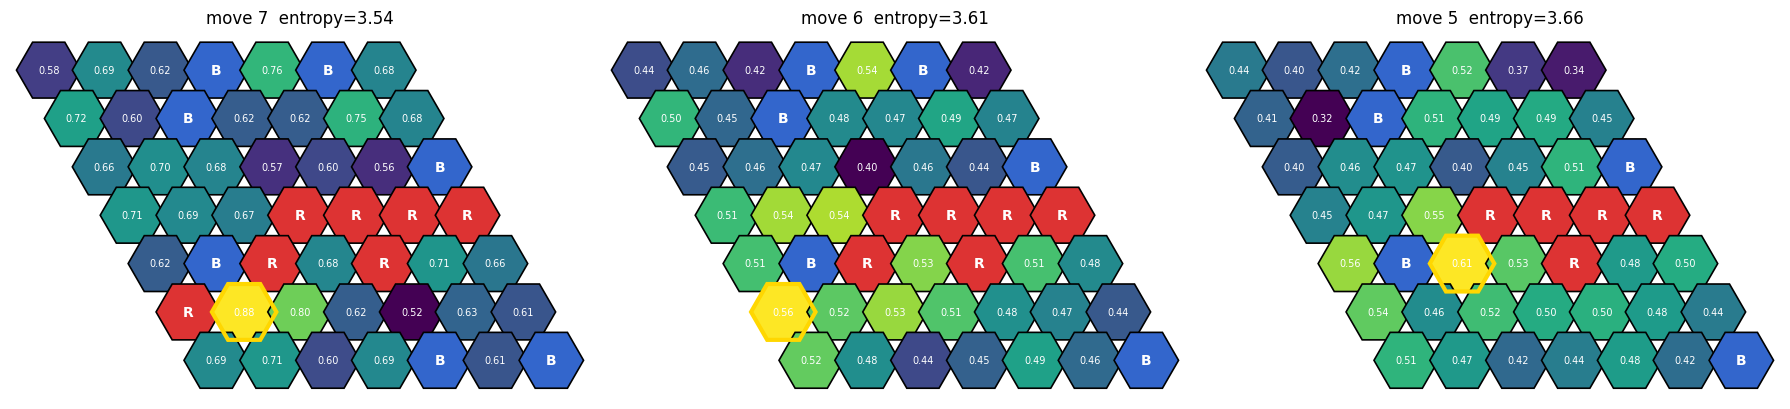

In [75]:
def entropy(p):
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)))

random.seed(7)
game = hexPosition(size=BOARD_SIZE)
ents, snaps, qsnaps = [], [], []

while game.winner == EMPTY:
    acts = legal_moves(game.board)
    if game.player == RED:
        q, _ = q_values_for(game.board, RED)
        ents.append(entropy(softmax(q, tau=0.5)))
        snaps.append(deepcopy(game.board))
        qsnaps.append(q)
        mv = best_move(game.board, RED)
    else:
        mv = random.choice(acts)
    game.move(mv)
    if len(ents) > BOARD_SIZE*BOARD_SIZE:
        break

print('winner:', 'RED' if game.winner == RED else 'BLUE')
print('entropies:', [round(e, 2) for e in ents])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ents, marker='o')
ax.set_xlabel('RED move #'); ax.set_ylabel('softmax entropy')
ax.set_title('RED policy entropy across one game')
ax.grid(True, alpha=0.3)
plt.show()

order = np.argsort(ents)[:3]
fig, axes = plt.subplots(1, len(order), figsize=(6*len(order), 5))
if len(order) == 1: axes = [axes]
for ax, idx in zip(axes, order):
    flat = qsnaps[idx].flatten()
    bm = (int(np.nanargmax(flat)) // BOARD_SIZE, int(np.nanargmax(flat)) % BOARD_SIZE)
    draw_board(snaps[idx], qsnaps[idx],
               title=f'move {idx}  entropy={ents[idx]:.2f}', highlight=bm, ax=ax)
plt.tight_layout(); plt.show()

## 6. BLUE-side analysis

The model is canonical-as-RED so BLUE just sees a mirrored+color-swapped board.
But the agent's *real* behavior when actually playing BLUE is still worth a look
since BLUE is the second mover and has a disadvantage in Hex.

best opening for BLUE (real coords): (0, 3)


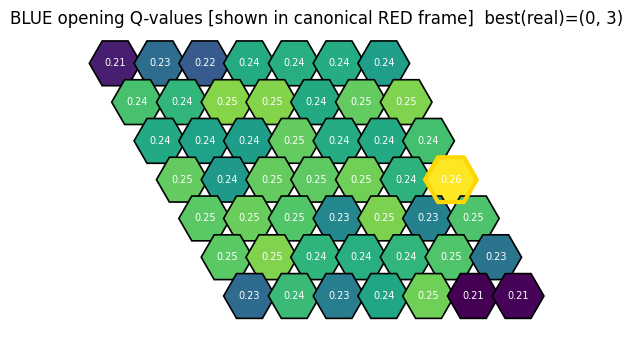

top 5 BLUE openings (real coords):
  (0, 3)  Q=0.260
  (4, 5)  Q=0.250
  (3, 5)  Q=0.250
  (5, 1)  Q=0.250
  (0, 5)  Q=0.250


In [76]:
# BLUE opening on empty board
q_blue, _ = q_values_for(empty, BLUE)
bm_blue = best_move(empty, BLUE)
print('best opening for BLUE (real coords):', bm_blue)

draw_board(empty, q_blue,
           title=f'BLUE opening Q-values [shown in canonical RED frame]  best(real)={bm_blue}',
           highlight=transform_move_for_blue(bm_blue, BOARD_SIZE))
plt.show()

ranked = sorted([(i, v) for i, v in enumerate(q_blue.flatten()) if not np.isnan(v)],
                key=lambda t: -t[1])
print('top 5 BLUE openings (real coords):')
for i, v in ranked[:5]:
    cm = (i // BOARD_SIZE, i % BOARD_SIZE)
    print(f'  {transform_move_for_blue(cm, BOARD_SIZE)}  Q={v:.3f}')

BLUE vs random RED : {1: 2, -1: 48} avg len 18.88
BLUE vs greedy RED : {1: 50, -1: 0} avg len 31.0


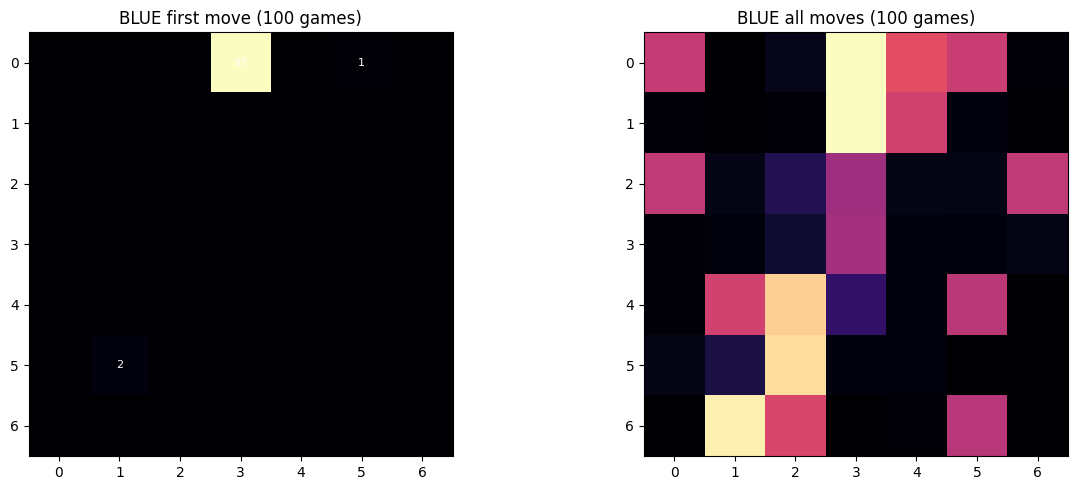

In [77]:
random.seed(1); torch.manual_seed(1)
fm_br, am_br, wins_br, len_br = play(random_agent,        model_agent, n_games=50)
fm_bg, am_bg, wins_bg, len_bg = play(greedy_center_agent, model_agent, n_games=50)
print('BLUE vs random RED :', wins_br, 'avg len', np.mean(len_br))
print('BLUE vs greedy RED :', wins_bg, 'avg len', np.mean(len_bg))

def collect_blue_moves(agent_red, agent_blue, n_games, board_size):
    n = board_size
    fm = np.zeros((n, n))
    am = np.zeros((n, n))
    for _ in range(n_games):
        game = hexPosition(size=board_size)
        first_done = False
        m = 0
        while game.winner == EMPTY:
            acts = legal_moves(game.board)
            cur = game.player
            mover = agent_red if cur == RED else agent_blue
            mv = mover([row[:] for row in game.board], acts)
            if cur == BLUE:
                am[mv] += 1
                if not first_done:
                    fm[mv] += 1
                    first_done = True
            game.move(mv)
            m += 1
            if m > board_size*board_size:
                break
    return fm, am

random.seed(2)
fmb_r, amb_r = collect_blue_moves(random_agent,        model_agent, 50, BOARD_SIZE)
fmb_g, amb_g = collect_blue_moves(greedy_center_agent, model_agent, 50, BOARD_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fm = fmb_r + fmb_g
axes[0].imshow(fm, cmap='magma'); axes[0].set_title('BLUE first move (100 games)')
for r in range(BOARD_SIZE):
    for c in range(BOARD_SIZE):
        if fm[r, c] > 0:
            axes[0].text(c, r, int(fm[r, c]), ha='center', va='center', color='white', fontsize=8)

axes[1].imshow(amb_r + amb_g, cmap='magma'); axes[1].set_title('BLUE all moves (100 games)')
plt.tight_layout(); plt.show()

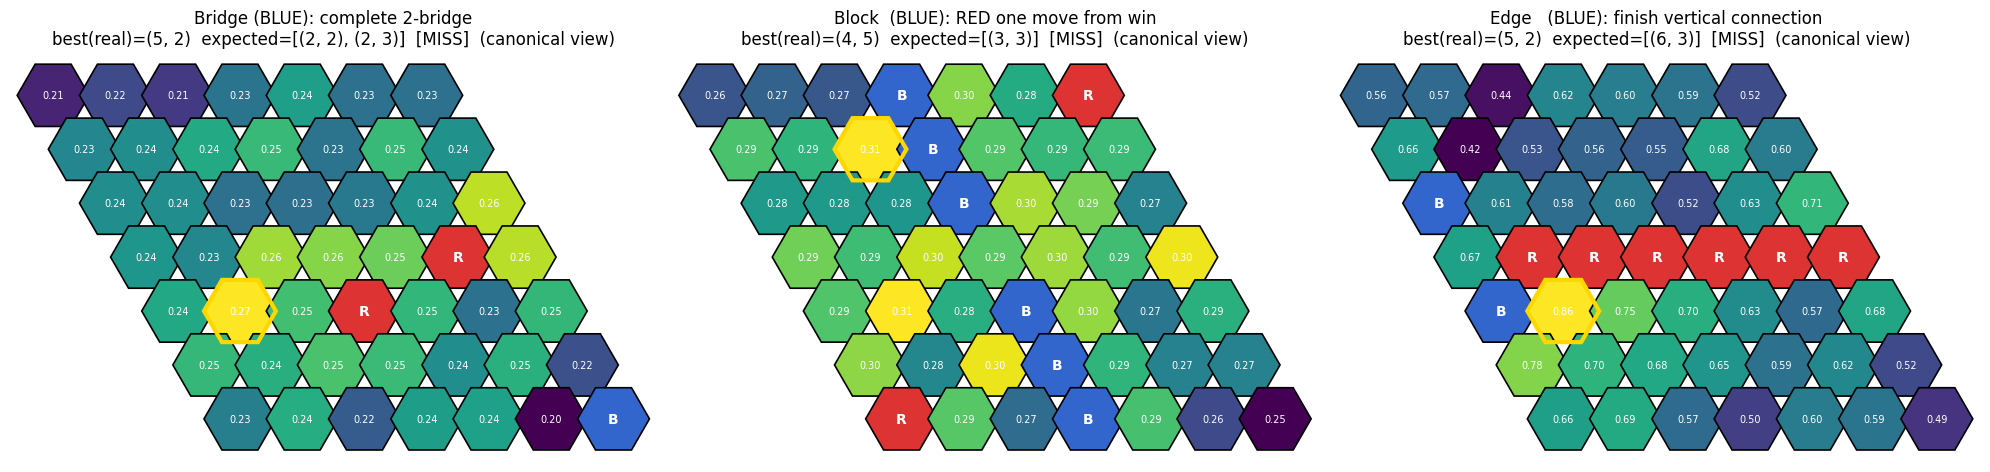

In [78]:
blue_bridge = make_board({(1,3):BLUE, (3,2):BLUE, (0,0):RED})           # complete at (2,2) or (2,3)
blue_block  = make_board({(3,0):RED,(3,1):RED,(3,2):RED,(3,4):RED,(3,5):RED,(3,6):RED,
                          (0,6):BLUE,(6,0):BLUE})                       # block at (3,3)
blue_edge   = make_board({(0,3):BLUE,(1,3):BLUE,(2,3):BLUE,(3,3):BLUE,(4,3):BLUE,(5,3):BLUE,
                          (6,2):RED,(6,4):RED})                         # finish at (6,3)

blue_probes = [
    ('Bridge (BLUE): complete 2-bridge',           blue_bridge, BLUE, [(2,2),(2,3)]),
    ('Block  (BLUE): RED one move from win',       blue_block,  BLUE, [(3,3)]),
    ('Edge   (BLUE): finish vertical connection',  blue_edge,   BLUE, [(6,3)]),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, b, p, expected) in zip(axes, blue_probes):
    q, _ = q_values_for(b, p)
    bm = best_move(b, p)
    cb = canonical_board(b, p)
    highlight_cm = transform_move_for_blue(bm, BOARD_SIZE)
    ok = 'OK' if bm in expected else 'MISS'
    draw_board(cb, q,
               title=f'{title}\nbest(real)={bm}  expected={expected}  [{ok}]  (canonical view)',
               highlight=highlight_cm, ax=ax)
plt.tight_layout(); plt.show()

## 7. Endgame: does it actually take winning moves?

During self-play, every time the agent has at least one move that immediately wins,
check whether it picks one. This isolates "can it close the game" from general play.

immediate-win take rate:
  RED  vs random : 49/76 = 64%
  RED  vs greedy : n/a
  BLUE vs random : 49/112 = 44%
  BLUE vs greedy : n/a


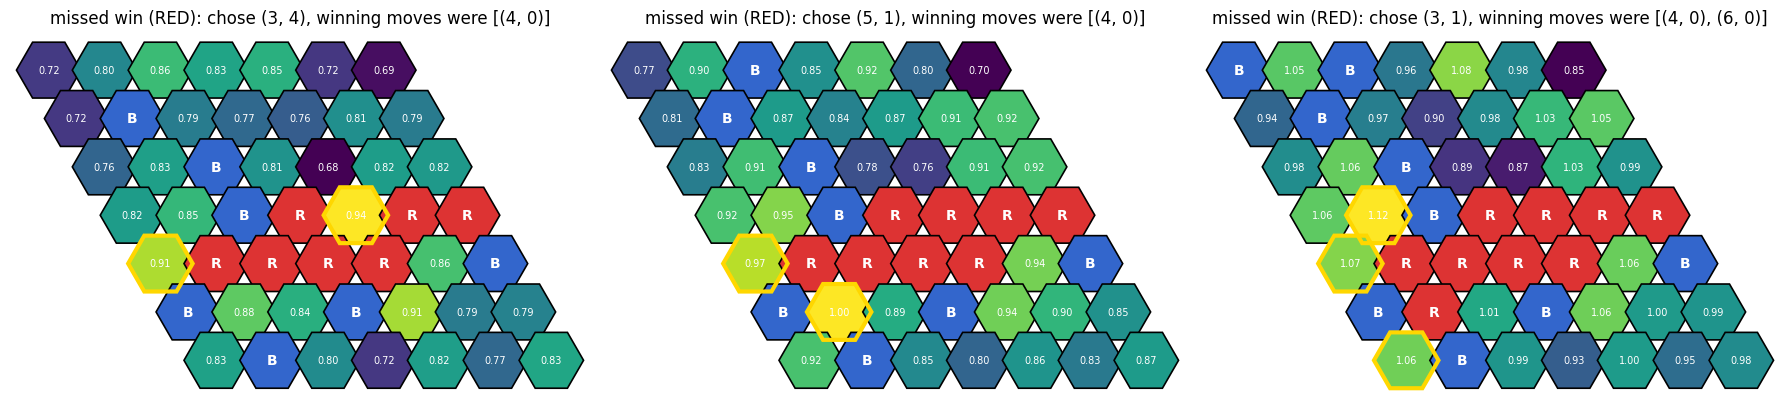

In [79]:
def winning_moves(board, player, board_size):
    wins = []
    for (r, c) in legal_moves(board):
        g = hexPosition(size=board_size)
        g.board = deepcopy(board)
        g.player = player
        try:
            g.move((r, c))
        except AssertionError:
            continue
        if g.winner == player:
            wins.append((r, c))
    return wins

def endgame_audit(model_side, opponent, n_games=50, board_size=BOARD_SIZE):
    n_opp = n_taken = 0
    misses = []
    for _ in range(n_games):
        game = hexPosition(size=board_size)
        m = 0
        while game.winner == EMPTY:
            acts = legal_moves(game.board)
            cur = game.player
            if cur == model_side:
                wins = winning_moves(game.board, cur, board_size)
                board_copy = [row[:] for row in game.board]
                mv = model_agent(board_copy, acts)
                if wins:
                    n_opp += 1
                    if mv in wins:
                        n_taken += 1
                    else:
                        misses.append((board_copy, cur, wins, mv))
            else:
                mv = opponent(game.board, acts)
            game.move(mv)
            m += 1
            if m > board_size*board_size:
                break
    return n_opp, n_taken, misses

random.seed(10); torch.manual_seed(10)
opp_r_rand, take_r_rand, miss_r_rand = endgame_audit(RED,  random_agent,        50)
opp_r_grd,  take_r_grd,  miss_r_grd  = endgame_audit(RED,  greedy_center_agent, 50)
opp_b_rand, take_b_rand, miss_b_rand = endgame_audit(BLUE, random_agent,        50)
opp_b_grd,  take_b_grd,  miss_b_grd  = endgame_audit(BLUE, greedy_center_agent, 50)

def rate(t, o):
    return f'{t}/{o} = {100*t/o:.0f}%' if o else 'n/a'

print('immediate-win take rate:')
print(f'  RED  vs random : {rate(take_r_rand, opp_r_rand)}')
print(f'  RED  vs greedy : {rate(take_r_grd,  opp_r_grd)}')
print(f'  BLUE vs random : {rate(take_b_rand, opp_b_rand)}')
print(f'  BLUE vs greedy : {rate(take_b_grd,  opp_b_grd)}')

all_misses = miss_r_rand + miss_r_grd + miss_b_rand + miss_b_grd
if all_misses:
    show = all_misses[:3]
    fig, axes = plt.subplots(1, len(show), figsize=(6*len(show), 5))
    if len(show) == 1: axes = [axes]
    for ax, (board, player, wins, mv) in zip(axes, show):
        q, _ = q_values_for(board, player)
        cb = canonical_board(board, player)
        if player == BLUE:
            mv_cm = transform_move_for_blue(mv, BOARD_SIZE)
            win_cm = [transform_move_for_blue(w, BOARD_SIZE) for w in wins]
        else:
            mv_cm, win_cm = mv, wins
        side = 'RED' if player == RED else 'BLUE'
        draw_board(cb, q,
                   title=f'missed win ({side}): chose {mv}, winning moves were {wins}',
                   highlight=[mv_cm] + win_cm, ax=ax)
    plt.tight_layout(); plt.show()
else:
    print('no missed wins')

## 8. Move patterns split by game phase

Bucket each move by how many stones are already on the board. Roughly:
opening (<=6 stones), middlegame (7-18), endgame (19+). Heatmap each phase
to see if the agent uses different parts of the board at different times.

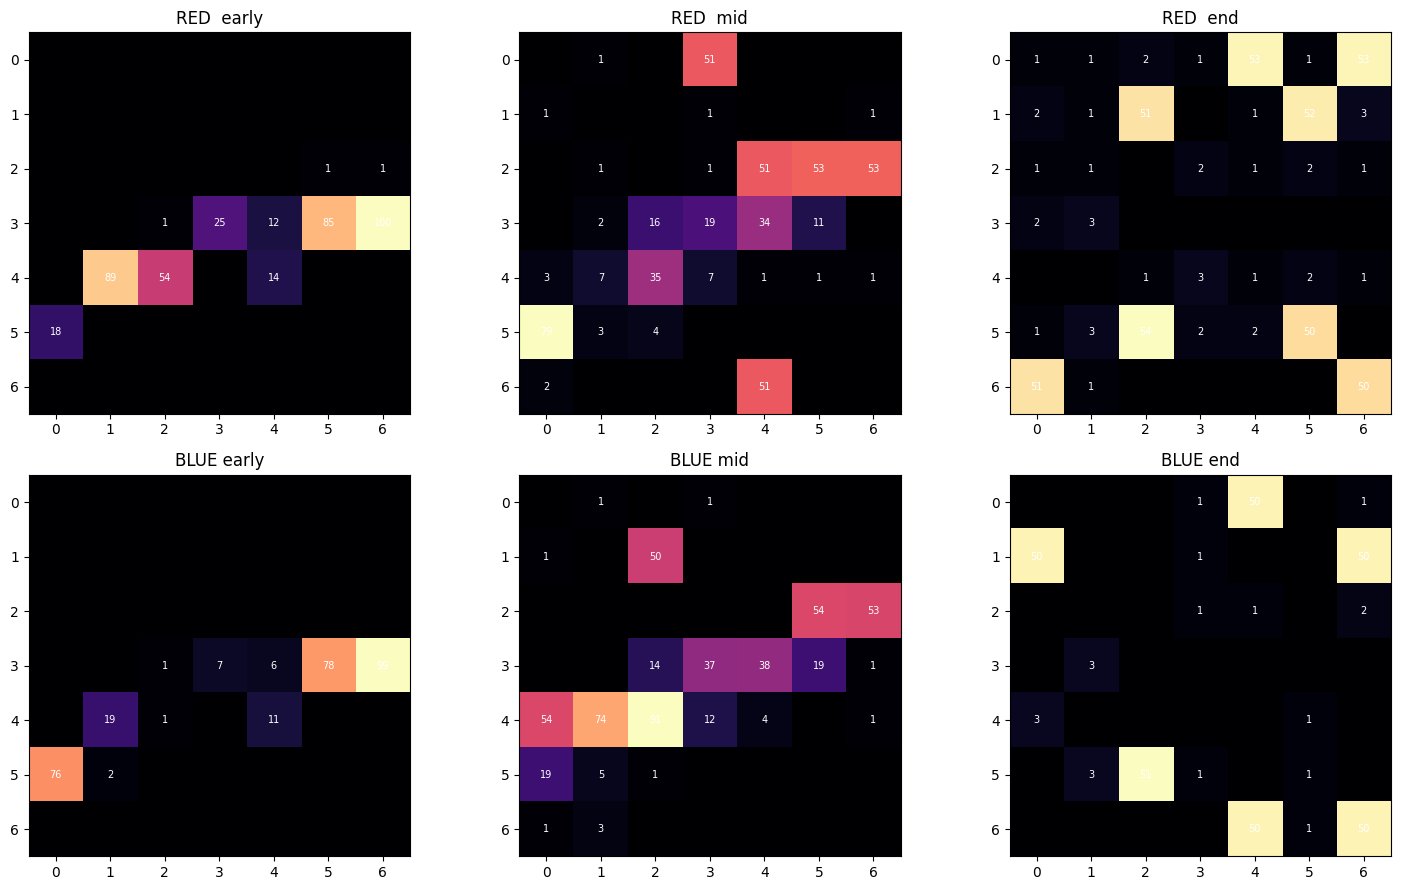

In [80]:
EARLY_MAX, MID_MAX = 6, 18

def collect_phase_heatmaps(model_side, opponent, n_games, board_size):
    n = board_size
    buckets = {'early': np.zeros((n,n)), 'mid': np.zeros((n,n)), 'end': np.zeros((n,n))}
    for _ in range(n_games):
        game = hexPosition(size=board_size)
        m = 0
        stones = 0
        while game.winner == EMPTY:
            acts = legal_moves(game.board)
            cur = game.player
            mover = model_agent if cur == model_side else opponent
            mv = mover([row[:] for row in game.board], acts)
            if cur == model_side:
                cm = transform_move_for_blue(mv, board_size) if cur == BLUE else mv
                if   stones <= EARLY_MAX: buckets['early'][cm] += 1
                elif stones <= MID_MAX:   buckets['mid'][cm]   += 1
                else:                     buckets['end'][cm]   += 1
            game.move(mv)
            stones += 1
            m += 1
            if m > board_size*board_size:
                break
    return buckets

random.seed(20); torch.manual_seed(20)
b_red  = collect_phase_heatmaps(RED,  random_agent,        50, BOARD_SIZE)
b_red2 = collect_phase_heatmaps(RED,  greedy_center_agent, 50, BOARD_SIZE)
b_blu  = collect_phase_heatmaps(BLUE, random_agent,        50, BOARD_SIZE)
b_blu2 = collect_phase_heatmaps(BLUE, greedy_center_agent, 50, BOARD_SIZE)

phases = ['early', 'mid', 'end']
red_combined  = {p: b_red[p]  + b_red2[p]  for p in phases}
blue_combined = {p: b_blu[p]  + b_blu2[p]  for p in phases}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for j, p in enumerate(phases):
    axes[0, j].imshow(red_combined[p],  cmap='magma'); axes[0, j].set_title(f'RED  {p}')
    axes[1, j].imshow(blue_combined[p], cmap='magma'); axes[1, j].set_title(f'BLUE {p}')
    for r in range(BOARD_SIZE):
        for c in range(BOARD_SIZE):
            if red_combined[p][r, c] > 0:
                axes[0, j].text(c, r, int(red_combined[p][r, c]),
                                ha='center', va='center', color='white', fontsize=7)
            if blue_combined[p][r, c] > 0:
                axes[1, j].text(c, r, int(blue_combined[p][r, c]),
                                ha='center', va='center', color='white', fontsize=7)
plt.tight_layout(); plt.show()

## 9. Stochastic evaluation

Problem with the deterministic numbers above: argmax model vs argmax greedy-center
means all 50 games are literally the same game. So 0/50 isn't 50 independent losses,
it's 1 loss repeated 50 times.

To get a real distribution: sample the agent's move from softmax(Q / tau).
With tau a bit above zero we still mostly pick high-Q moves but games actually differ.

In [81]:
TAU = 0.3

def model_agent_stochastic(board, action_set, tau=TAU):
    n = len(board)
    red  = sum(v == RED  for row in board for v in row)
    blue = sum(v == BLUE for row in board for v in row)
    player = RED if red == blue else BLUE

    q, _ = q_values_for(board, player)
    flat = q.flatten()
    legal_cm = action_set if player == RED else [transform_move_for_blue(m, n) for m in action_set]
    idxs = [r*n + c for (r, c) in legal_cm]
    vals = np.array([flat[i] for i in idxs])
    vals -= np.nanmax(vals)
    probs = np.exp(vals / tau)
    probs /= probs.sum()
    pick = np.random.choice(len(idxs), p=probs)
    cm = legal_cm[pick]
    return transform_move_for_blue(cm, n) if player == BLUE else cm

def play_stochastic(agent_red, agent_blue, n_games=50, board_size=BOARD_SIZE):
    rw = bw = 0
    lens = []
    for _ in range(n_games):
        game = hexPosition(size=board_size)
        m = 0
        while game.winner == EMPTY:
            acts = legal_moves(game.board)
            mover = agent_red if game.player == RED else agent_blue
            mv = mover([row[:] for row in game.board], acts)
            game.move(mv); m += 1
            if m > board_size*board_size:
                break
        if game.winner == RED:  rw += 1
        if game.winner == BLUE: bw += 1
        lens.append(m)
    return rw, bw, lens

random.seed(42); np.random.seed(42); torch.manual_seed(42)
N = 100

r1, b1, l1 = play_stochastic(model_agent_stochastic, random_agent,        n_games=N)
r2, b2, l2 = play_stochastic(model_agent_stochastic, greedy_center_agent, n_games=N)
r3, b3, l3 = play_stochastic(random_agent,           model_agent_stochastic, n_games=N)
r4, b4, l4 = play_stochastic(greedy_center_agent,    model_agent_stochastic, n_games=N)

print(f'tau={TAU}, {N} games per matchup:')
print(f'  RED  vs random        : {r1}/{N} ({100*r1/N:.0f}%)  avg len {np.mean(l1):.1f}')
print(f'  RED  vs greedy-center : {r2}/{N} ({100*r2/N:.0f}%)  avg len {np.mean(l2):.1f}')
print(f'  BLUE vs random        : {b3}/{N} ({100*b3/N:.0f}%)  avg len {np.mean(l3):.1f}')
print(f'  BLUE vs greedy-center : {b4}/{N} ({100*b4/N:.0f}%)  avg len {np.mean(l4):.1f}')

stoch_results = {
    ('RED',  'random'):        (r1, N, np.mean(l1)),
    ('RED',  'greedy-center'): (r2, N, np.mean(l2)),
    ('BLUE', 'random'):        (b3, N, np.mean(l3)),
    ('BLUE', 'greedy-center'): (b4, N, np.mean(l4)),
}

tau=0.3, 100 games per matchup:
  RED  vs random        : 51/100 (51%)  avg len 40.8
  RED  vs greedy-center : 44/100 (44%)  avg len 41.5
  BLUE vs random        : 51/100 (51%)  avg len 41.4
  BLUE vs greedy-center : 36/100 (36%)  avg len 39.1


## 10. Summary table

Putting everything in one place.

In [82]:
def fmt_winrate(wins, side):
    total = wins.get(RED, 0) + wins.get(BLUE, 0)
    return f'{wins.get(side, 0)}/{total} ({100*wins.get(side, 0)/total:.0f}%)' if total else 'n/a'

def stoch_cell(side, opp):
    w, n, _ = stoch_results[(side, opp)]
    return f'{w}/{n} ({100*w/n:.0f}%)'

probe_ok_red  = sum(1 for t, b, p, e in probes      if best_move(b, p) in e)
probe_ok_blue = sum(1 for t, b, p, e in blue_probes if best_move(b, p) in e)

rows = [
    ('Side', 'Opponent',      'Det. win rate', 'Stoch. win rate (tau=0.3)', 'Avg len', 'Endgame win-take'),
    ('----', '-------------', '-------------', '-------------------------', '-------', '----------------'),
    ('RED',  'random',        fmt_winrate(wins_r,  RED),  stoch_cell('RED',  'random'),        f'{np.mean(len_r):.1f}',  rate(take_r_rand, opp_r_rand)),
    ('RED',  'greedy-center', fmt_winrate(wins_g,  RED),  stoch_cell('RED',  'greedy-center'), f'{np.mean(len_g):.1f}',  rate(take_r_grd,  opp_r_grd)),
    ('BLUE', 'random',        fmt_winrate(wins_br, BLUE), stoch_cell('BLUE', 'random'),        f'{np.mean(len_br):.1f}', rate(take_b_rand, opp_b_rand)),
    ('BLUE', 'greedy-center', fmt_winrate(wins_bg, BLUE), stoch_cell('BLUE', 'greedy-center'), f'{np.mean(len_bg):.1f}', rate(take_b_grd,  opp_b_grd)),
]

widths = [max(len(str(r[i])) for r in rows) for i in range(len(rows[0]))]
print(f'model: {os.path.basename(CKPT)}  (episodes={checkpoint.get("episodes")})')
print()
for row in rows:
    print('  ' + '  '.join(str(c).ljust(w) for c, w in zip(row, widths)))
print()
print(f'probes passed: RED {probe_ok_red}/{len(probes)}   BLUE {probe_ok_blue}/{len(blue_probes)}')
print()
print('RED probes:')
for title, b, p, expected in probes:
    bm = best_move(b, p)
    tag = 'OK  ' if bm in expected else 'MISS'
    print(f'  [{tag}] {title}: best={bm}  expected={expected}')
print('BLUE probes:')
for title, b, p, expected in blue_probes:
    bm = best_move(b, p)
    tag = 'OK  ' if bm in expected else 'MISS'
    print(f'  [{tag}] {title}: best={bm}  expected={expected}')

model: phase5_cnn_reward_shaping_soft_path_block_7x7_best.pt  (episodes=1500)

  Side  Opponent       Det. win rate  Stoch. win rate (tau=0.3)  Avg len  Endgame win-take
  ----  -------------  -------------  -------------------------  -------  ----------------
  RED   random         49/50 (98%)    51/100 (51%)               16.0     49/76 = 64%     
  RED   greedy-center  0/50 (0%)      44/100 (44%)               36.0     n/a             
  BLUE  random         48/50 (96%)    51/100 (51%)               18.9     49/112 = 44%    
  BLUE  greedy-center  0/50 (0%)      36/100 (36%)               31.0     n/a             

probes passed: RED 1/3   BLUE 0/3

RED probes:
  [MISS] Bridge (RED): complete the 2-bridge: best=(3, 6)  expected=[(2, 2), (3, 2)]
  [MISS] Block  (RED): BLUE one move from win: best=(3, 6)  expected=[(4, 3)]
  [OK  ] Edge   (RED): finish horizontal connection: best=(3, 6)  expected=[(3, 6)]
BLUE probes:
  [MISS] Bridge (BLUE): complete 2-bridge: best=(5, 2)  expected=[(

### Notes

**What works**
- against random it wins almost everything, 49/50 as RED and 48/50 as BLUE. even
  with stochastic sampling (tau=0.3) it's still around 51% which is fine
- endgame check: when there's a one-move win available it actually takes it most of
  the time (64% as RED, 44% as BLUE). better than nothing
- the RED edge defense probe passes, it plays (3,6) to close the row

**What doesn't work**
- the agent basically always wants to play (3,6) as RED. all three probes return
  (3,6). so the edge probe passing is kind of a fluke, the expected move just
  happens to be (3,6) too
- BLUE has the same issue with a different cell, it keeps picking (5,2) or (4,5)
- vs greedy-center it loses 0/50 deterministic, and even stochastic only gets to
  44%/36%. Greedy-center is a pretty dumb baseline so this is not good
- the heatmaps kind of confirm it, the agent plays in basically the same corner
  the whole time

**About the 0/50:**
both agents being deterministic means all 50 games are literally the same game,
so 0/50 is really 1 loss x 50. that's why I added the stochastic eval, tau=0.3
makes games actually different from each other